In [1]:
import numpy as np
import scipy.io
from sklearn import metrics
import pandas as pd
import os
import scipy.io as sio
import os.path
import time
import random
import math

import tensorflow.keras as keras
import tensorflow as tf
import matplotlib.pyplot as plt

from keras.layers import Embedding
from keras.models import Model
from keras.layers import Dense, Dropout, Activation, Flatten, Layer, merge, Input, Concatenate, Reshape
from keras.layers.convolutional import Conv1D, MaxPooling1D
from keras.layers.pooling import GlobalMaxPooling1D
from keras.layers.recurrent import LSTM
from keras.layers.wrappers import Bidirectional, TimeDistributed
from keras.models import load_model
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras import backend as K
import tensorflow.keras as keras
import tensorflow as tf
import matplotlib.pyplot as plt

In [119]:
gpu_devices = tf.config.experimental.list_physical_devices('GPU')
for device in gpu_devices:
    tf.config.experimental.set_memory_growth(device, True)

In [3]:
# Library of Helper Functions

def readInputAsArray(fileName):
    with open(fileName, 'r') as myfile:
        data = myfile.readlines()

    # Strip newline
    for i in range(0, len(data)):
        data[i] = data[i].rstrip()
    # print(data)
    return data

def readInputAsString(fileName):
    with open(fileName, 'r') as myfile:
        data=myfile.read().replace('\n', ' ')
        # print 
    return data

def reverse_complement(seq):    
    complement = {'A': 'T', 'C': 'G', 'G': 'C', 'T': 'A'}
    reverse_complement = ''.join(complement.get(base, base) for base in reversed(seq))
    return reverse_complement

def oneHotEncode(seq):
    import numpy as np
    seq2=list()
    mapping = {"A":[1., 0., 0., 0.], "C": [0., 1., 0., 0.], "G": [0., 0., 1., 0.], "T":[0., 0., 0., 1.]};
    for i in seq:
    	seq2.append(mapping[i]  if i in mapping.keys() else [0., 0., 0., 0.]);
    return seq2;

def ReverseOneHotEncode(arr):
    seq = ''
    nuc_map = ['A', 'C', 'G', 'T']
    for subarr in arr:
        nuc = nuc_map[np.argmax(subarr)]
        seq+=nuc
    return seq;

def writeSeqToFile(d,ones,zeros):
    fname = '/Users/yibeijia/Downloads/nucleosome_occupancy/data/SeqsForFeature.txt'
    fname='/home/yibei/Projects/nucleosome_occupancy/data/SeqsForFeature.txt'
    out = 'Enriched:\n'
    for i in ones:
        seq = ReverseOneHotEncode(d[i])
        out = out + str(1) + ' ' + seq + '\n'
    out += 'Depleted:\n'
    for i in zeros:
        seq = ReverseOneHotEncode(d[i])
        out = out + str(0) + ' ' + seq + '\n'
    with open(fname, 'w+') as f:
        f.write(out)      
        
def tokenize(str):
    out = []
    for i in range(len(str)-4):
        out.append(str[i:i+5])
    return out

# Normalize an array 
def min_max_norm(arr):
    new_arr = []
    min_v = min(arr)
    max_v = max(arr)
    for num in arr:
        new_arr=new_arr+[(num-min_v)/(max_v-min_v)]
    return(new_arr)

def read_SD_table(fileName):
    tb_data = readInputAsArray(fileName)
    tb = {}
    DNAshape = tb_data[0].split("\t")
    # print(DNAshape)
    for i in range(1, len(tb_data)):
        line = tb_data[i].split("\t")
        key = line[0]
        value = line[1:]
        for j in range(0, len(value)):
            value[j] = float(value[j])
        tb[key] = value
    # print(tb)
    return(tb)

In [4]:
# Helper function to plot data colored with attention weights
class CharVal(object):
    def __init__(self, char, val):
        self.char = char
        self.val = val

    def __str__(self):
        return self.char

def rgb_to_hex(rgb):
    return '#%02x%02x%02x' % rgb

def color_charvals(s):
    r = 255-int(s.val*255)
#     r = int(s.val*255)
#     print(r)
    color = rgb_to_hex((r, r, 255))
    return 'background-color: %s' % color

# a list of 5mers, token and a list of their attention values, currseq_attention_output
def plot_attention_from_seq(token, currseq_attention_output):

    vals_normalized = min_max_norm(currseq_attention_output)
#     print(vals_normalized)
    # match each 5mer with sum of the 320 dim array attention weight array
    char_vals = [CharVal(c, v) for c, v in zip(token, vals_normalized)]
    char_df = pd.DataFrame(char_vals).transpose()
    # apply coloring values
    char_df = char_df.style.applymap(color_charvals)
    return char_df


def plot_attention_from_map(map):

    # match each 5mer with sum of the 320 dim array attention weight array
    vals_normalized = min_max_norm(map.values())
    char_vals = [CharVal(c, v) for c, v in zip(map.keys(), vals_normalized)]
    char_df = pd.DataFrame(char_vals).transpose()
    # apply coloring values
    char_df = char_df.style.applymap(color_charvals)
    return char_df

In [5]:
data_folder = "/Users/yibeijia/Downloads/nucleosome_occupancy/tbinet_stuff/model2/"

data_folder = "/Users/yibeijia/Downloads/nucleosome_occupancy/tbinet_stuff/model2_reduced_dense10/"
data_folder = "/Users/yibeijia/Downloads/nucleosome_occupancy/tbinet_stuff/model3/"
data_folder = "/Users/yibeijia/Downloads/nucleosome_occupancy/tbinet_stuff/train_dense10_kernel10_run3/"
# data_folder = "/home/yibei/Projects/nucleosome_occupancy/tbinet_stuff/train_dense10_kernel10_run3/"
model = load_model(data_folder+"tbinet.h5")

model.summary()



Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 147, 4)]     0                                            
__________________________________________________________________________________________________
conv1d (Conv1D)                 (None, 147, 320)     13120       input_1[0][0]                    
__________________________________________________________________________________________________
max_pooling1d (MaxPooling1D)    (None, 143, 320)     0           conv1d[0][0]                     
__________________________________________________________________________________________________
dropout (Dropout)               (None, 143, 320)     0           max_pooling1d[0][0]              
______________________________________________________________________________________________

# 1. Generate Attention weights for all data

In [7]:
def generateAttentionWeights(model):
    ## load model with its attention weights using the "Multiply layer" 
    attention_wt_model = tf.keras.models.Model(inputs=model.inputs, outputs=[model.output, model.get_layer('multiply').output])

    ## Set up a set of data for predict call, this case, taking every 10 data point
#     data_folder = "/home/yibei/Projects/nucleosome_occupancy/data/train_test_data/"
    data_folder = "/Users/yibeijia/Downloads/nucleosome_occupancy/data/train_test_data/"

    # load testmat from file
    testmat = scipy.io.loadmat(data_folder+'Test_data.mat')
    batches = 100
    batch_size = round(len(testmat['Test_data'])/batches)
    print(f"batch_size: {batch_size}; batches: {batches}")
    model_outputs=[]
    attention_outputs=[]
    model_outputs0=[]
    attention_outputs0=[]
    model_outputs1=[]
    attention_outputs1=[]

    for i in range(batches):
    # for i in range(2):
        start = i*batch_size
        end = (i+1)*batch_size
        print(f"start: {start}; end: {end}")
        d = testmat['Test_data'][start:end]
        labels = testmat['Test_labels']
        new_labels = labels[0][start:end]

        # get the index of data that is 0 or 1 
        ones = np.flatnonzero(new_labels == np.max(new_labels))
        zeros = np.flatnonzero(new_labels == np.min(new_labels))
    #     print(f'ones.shape {ones.shape}')
    #     print(f'zeros.shape {zeros.shape}')

        # # get all model output and attention weights
        attention_wt = attention_wt_model.predict(np.transpose(d,axes=(0,1,2)))
        model_out = attention_wt[0]
        attention_out = attention_wt[1]
    #     print(f'model.shape {len(model_out)}')

        # separate 0 and 1
        attention_out0 = [attention_out[i] for i in zeros]
        attention_out1 = [attention_out[i] for i in ones]
#         model_out0 = [model_out[i] for i in zeros]
#         model_out1 = [model_out[i] for i in ones]

        # Concatenate current batch with the rest of batches
        if len(attention_outputs) == 0: # if initialize
#             model_outputs = model_out
#             model_outputs0 = model_out0
#             model_outputs1 = model_out1

            attention_outputs = attention_out
            attention_outputs0 = attention_out0
            attention_outputs1 = attention_out1

        else:
#             model_outputs = np.concatenate((model_outputs, model_out), axis=0)
#             model_outputs1 = np.concatenate((model_outputs1, model_out1), axis=0)
#             model_outputs0 = np.concatenate((model_outputs0, model_out0), axis=0)
            attention_outputs = np.concatenate((attention_outputs, attention_out), axis=0)
            attention_outputs0 = np.concatenate((attention_outputs0, attention_out0), axis=0)
            attention_outputs1 = np.concatenate((attention_outputs1, attention_out1), axis=0)

    r = len(attention_outputs)
    c = len(attention_outputs[0])
    l = len(attention_outputs[0][0])
    print(f"The all attention_outputs Array is {r} x {c} x {l}")

    r = len(attention_outputs0)
    c = len(attention_outputs0[0])
    l = len(attention_outputs0[0][0])
    print(f"The 0 attention_outputs Array is {r} x {c} x {l}")

    r = len(attention_outputs1)
    c = len(attention_outputs1[0])
    l = len(attention_outputs1[0][0])
    print(f"The 1 attention_outputs Array is {r} x {c} x {l}")
    return attention_outputs, attention_outputs0, attention_outputs1

In [8]:
attention_outputs, attention_outputs0, attention_outputs1 = generateAttentionWeights(model)

batch_size: 1509; batches: 100
start: 0; end: 1509
start: 1509; end: 3018
start: 3018; end: 4527
start: 4527; end: 6036
start: 6036; end: 7545
start: 7545; end: 9054
start: 9054; end: 10563
start: 10563; end: 12072
start: 12072; end: 13581
start: 13581; end: 15090
start: 15090; end: 16599
start: 16599; end: 18108
start: 18108; end: 19617
start: 19617; end: 21126
start: 21126; end: 22635
start: 22635; end: 24144
start: 24144; end: 25653
start: 25653; end: 27162
start: 27162; end: 28671
start: 28671; end: 30180
start: 30180; end: 31689
start: 31689; end: 33198
start: 33198; end: 34707
start: 34707; end: 36216
start: 36216; end: 37725
start: 37725; end: 39234
start: 39234; end: 40743
start: 40743; end: 42252
start: 42252; end: 43761
start: 43761; end: 45270
start: 45270; end: 46779
start: 46779; end: 48288
start: 48288; end: 49797
start: 49797; end: 51306
start: 51306; end: 52815
start: 52815; end: 54324
start: 54324; end: 55833
start: 55833; end: 57342
start: 57342; end: 58851
start: 588

In [9]:
print(len(attention_outputs))
print(len(attention_outputs0))
print(len(attention_outputs1))

150890
91621
59269


# 1. Plot attention score from run10 model for all 5mers

In [356]:
# # if you are using batches the outputs will be in batches
# # get exact attentions of chars
# i=0 #get attention map for ith sequence
# currseq_attention_output = sum(attention_outputs[i])
# token = tokenize(ReverseOneHotEncode(d[i]))
# char_df = plot_attention_from_seq(token, currseq_attention_output)
# (char_df)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142
0,CATGC,ATGCT,TGCTA,GCTAT,CTATC,TATCT,ATCTT,TCTTG,CTTGT,TTGTT,TGTTT,GTTTT,TTTTT,TTTTG,TTTGT,TTGTG,TGTGC,GTGCT,TGCTA,GCTAT,CTATG,TATGT,ATGTT,TGTTA,GTTAA,TTAAA,TAAAA,AAAAG,AAAGT,AAGTG,AGTGG,GTGGA,TGGAA,GGAAG,GAAGA,AAGAC,AGACC,GACCC,ACCCA,CCCAG,CCAGA,CAGAT,AGATG,GATGT,ATGTT,TGTTA,GTTAT,TTATC,TATCA,ATCAT,TCATA,CATAG,ATAGG,TAGGC,AGGCC,GGCCA,GCCAT,CCATC,CATCG,ATCGT,TCGTT,CGTTT,GTTTG,TTTGC,TTGCA,TGCAA,GCAAA,CAAAA,AAAAT,AAATG,AATGT,ATGTC,TGTCT,GTCTA,TCTAC,CTACT,TACTT,ACTTA,CTTAG,TTAGA,TAGAT,AGATG,GATGT,ATGTT,TGTTT,GTTTT,TTTTA,TTTAG,TTAGC,TAGCT,AGCTC,GCTCA,CTCAT,TCATA,CATAG,ATAGA,TAGAA,AGAAT,GAATG,AATGC,ATGCA,TGCAT,GCATG,CATGA,ATGAT,TGATC,GATCT,ATCTC,TCTCA,CTCAA,TCAAC,CAACA,AACAT,ACATT,CATTC,ATTCC,TTCCA,TCCAA,CCAAC,CAACG,AACGT,ACGTT,CGTTC,GTTCA,TTCAG,TCAGC,CAGCT,AGCTC,GCTCT,CTCTA,TCTAT,CTATT,TATTG,ATTGG,TTGGC,TGGCC,GGCCG,GCCGT,CCGTC,CGTCG,GTCGT,TCGTT,CGTTT


In [357]:
# mapped = dict(zip(token, currseq_attention_output))
# print(mapped)

{'CATGC': 0.31830943, 'ATGCT': 0.016259491, 'TGCTA': 0.05800696, 'GCTAT': 0.19455113, 'CTATC': 0.18132968, 'TATCT': 0.47961965, 'ATCTT': 0.14670761, 'TCTTG': 0.08188573, 'CTTGT': 0.13063614, 'TTGTT': 0.30594188, 'TGTTT': 0.12208975, 'GTTTT': 0.2825193, 'TTTTT': 0.29415622, 'TTTTG': 0.34815067, 'TTTGT': 0.08404341, 'TTGTG': 0.331254, 'TGTGC': 0.040244393, 'GTGCT': 0.12662192, 'CTATG': 0.11822446, 'TATGT': 0.124241985, 'ATGTT': 0.13544737, 'TGTTA': 0.24178177, 'GTTAA': 0.26334694, 'TTAAA': 0.11507716, 'TAAAA': 0.3903092, 'AAAAG': 0.27615893, 'AAAGT': 0.16646147, 'AAGTG': 0.26397797, 'AGTGG': 0.036835663, 'GTGGA': 0.34128472, 'TGGAA': 0.312187, 'GGAAG': 0.045469657, 'GAAGA': 0.049688682, 'AAGAC': 0.117736265, 'AGACC': 0.13801822, 'GACCC': 0.25526172, 'ACCCA': 0.044001736, 'CCCAG': 0.4706448, 'CCAGA': 0.19629858, 'CAGAT': 0.1563096, 'AGATG': 0.21059515, 'GATGT': 0.30152336, 'GTTAT': 0.2057088, 'TTATC': 0.061627127, 'TATCA': 0.2909711, 'ATCAT': 0.2032266, 'TCATA': 0.3828196, 'CATAG': 0.3144

## 1.1 Don't add reverse Complements scores and treat them separately

In [13]:
# Put all the 5mers and their added total attention scores across sequences in dictionary
def sumAttentionforAllKmers(attention_outputs, d):
    from IPython.display import display
    mapped = {}
    kmerCounts = {}

    print(f"Total Attention Seq Num: {len(attention_outputs)}")
    print(f"Total Data Seq: {len(d)}")
    
    for seq in range(len(attention_outputs)):
    # for seq in range(1,500):

        # tokens are the 5mers in the current sequence
        tokens = tokenize(ReverseOneHotEncode(d[seq]))

        # for 147bp each sequence, there are 320 feature scores for each bp
        #     for i in range(len(attention_outputs[0])):
        for i in range(len(tokens)):
    #         print(token)
            token = tokens[i]
            if token in kmerCounts.keys():
                kmerCounts[token] = kmerCounts[token] + 1
            else:
                kmerCounts[token] = 1
            five_mer_attention_output = sum(attention_outputs[seq][i])
            if token in mapped.keys():  # if a 5mer is found
                mapped[token] = mapped[token] + five_mer_attention_output #increase value
            else: #if 5mer not seen yet
                mapped[token] = five_mer_attention_output
    #     char_df = plot_attention_from_seq(tokens, mapped[token])
    #     display(char_df)

    # Plot the mapped dictionary for each 5 mer; Darker means higher attention score
    import collections

    # char_df = plot_attention_from_map(mapped)
    # display(char_df)

    ordered_map = collections.OrderedDict(sorted(mapped.items()))
    return ordered_map, kmerCounts

# displayLength= 16
# print(len(list(ordered_map.items()))/displayLength)
# for i in range(int(len(list(ordered_map.items()))/displayLength)):
#     display_dict = dict(list(ordered_map.items())[i*displayLength:(i+1)*displayLength])
#     char_df = plot_attention_from_map(display_dict)
#     display(char_df)

In [16]:
data_folder = "/Users/yibeijia/Downloads/nucleosome_occupancy/data/train_test_data/"

# load testmat from file
testmat = scipy.io.loadmat(data_folder+'Test_data.mat')
d=testmat['Test_data'] # need to redefine d
labels = testmat['Test_labels']
new_labels = labels[0]

# get the index of data that is 0 or 1 
ones = np.flatnonzero(new_labels == np.max(new_labels))
zeros = np.flatnonzero(new_labels == np.min(new_labels))
d0 = [d[i] for i in zeros]
d1 = [d[i] for i in ones]

ordered_map0, kmerCounts0 = sumAttentionforAllKmers(attention_outputs0, d0)
ordered_map1, kmerCounts1 = sumAttentionforAllKmers(attention_outputs1, d1)
ordered_map, kmerCounts = sumAttentionforAllKmers(attention_outputs, d)


Total Attention Seq Num: 91621
Total Data Seq: 91621
Total Attention Seq Num: 59269
Total Data Seq: 59269
Total Attention Seq Num: 150890
Total Data Seq: 150890


In [17]:
# print(ordered_kmerCounts.keys())
# ordered_map = collections.OrderedDict(sorted(mapped.items()))
def normKmerCount(ordered_map, kmerCounts):
    ordered_map_norm = {}
    for k, _ in ordered_map.items():
        v = ordered_map[k] / kmerCounts[k]
        ordered_map_norm[k] = v
    return ordered_map_norm

In [19]:
ordered_map_norm = normKmerCount(ordered_map, kmerCounts)
ordered_map_norm0 = normKmerCount(ordered_map0, kmerCounts0)
ordered_map_norm1 = normKmerCount(ordered_map1, kmerCounts1)

print(len(ordered_map_norm))
# print(len(ordered_map))
print(len(ordered_map_norm0))
print(len(ordered_map_norm1))

1024
1024
1024


In [20]:
ordered_map0

OrderedDict([('AAAAA', 124493.44967384054),
             ('AAAAC', 19068.93264259258),
             ('AAAAG', 26979.443482888724),
             ('AAAAT', 52754.60613390001),
             ('AAACA', 11402.200241284227),
             ('AAACC', 5093.387425840192),
             ('AAACG', 5467.004703965762),
             ('AAACT', 8935.227934509521),
             ('AAAGA', 18060.915690511625),
             ('AAAGC', 5467.12281188911),
             ('AAAGG', 10616.915021294335),
             ('AAAGT', 17338.816335944473),
             ('AAATA', 54546.32796151558),
             ('AAATC', 15122.462287575574),
             ('AAATG', 15714.925410571512),
             ('AAATT', 50913.890145454716),
             ('AACAA', 15339.01278230725),
             ('AACAC', 4203.083197043906),
             ('AACAG', 5778.382987013012),
             ('AACAT', 15428.580368307777),
             ('AACCA', 5097.224405273422),
             ('AACCC', 2972.7307128180687),
             ('AACCG', 2305.034883353937),
 

In [21]:
kmerCounts0

{'CGGAA': 8037,
 'GGAAT': 16226,
 'GAATA': 25842,
 'AATAG': 23306,
 'ATAGC': 9497,
 'TAGCT': 8267,
 'AGCTT': 13283,
 'GCTTC': 10439,
 'CTTCA': 19518,
 'TTCAC': 14917,
 'TCACT': 13120,
 'CACTG': 7045,
 'ACTGA': 12812,
 'CTGAC': 6686,
 'TGACT': 11135,
 'GACTG': 5670,
 'ACTGC': 7307,
 'CTGCG': 3074,
 'TGCGT': 5094,
 'GCGTG': 2548,
 'CGTGT': 4083,
 'GTGTA': 9004,
 'TGTAT': 22624,
 'GTATT': 22449,
 'TATTT': 61898,
 'ATTTC': 34704,
 'TTTCT': 51279,
 'TTCTG': 18005,
 'TCTGC': 7921,
 'CTGCT': 8949,
 'TGCTT': 15192,
 'CTTCT': 24892,
 'TCTGT': 12779,
 'CTGTA': 9998,
 'TGTAG': 10799,
 'GTAGT': 11035,
 'TAGTT': 19069,
 'AGTTG': 13784,
 'GTTGA': 15822,
 'TTGAA': 38528,
 'TGAAG': 21112,
 'GAAGT': 15948,
 'AAGTG': 13162,
 'AGTGC': 5447,
 'GTGCA': 5725,
 'TGCAT': 11984,
 'GCATG': 5924,
 'CATGT': 9598,
 'ATGTT': 21708,
 'TGTTA': 19943,
 'GTTAA': 16160,
 'TTAAC': 17224,
 'TAACG': 8195,
 'AACGA': 12459,
 'ACGAA': 12585,
 'CGAAG': 7752,
 'GAAGC': 10945,
 'AAGCC': 7303,
 'AGCCT': 6176,
 'GCCTT': 8442,
 'CC

In [22]:
ordered_map_norm0

{'AAAAA': 0.6759959909093605,
 'AAAAC': 0.5359151436848008,
 'AAAAG': 0.5126053253322831,
 'AAAAT': 0.6525885542114575,
 'AAACA': 0.35773853234035785,
 'AAACC': 0.32375968890415663,
 'AAACG': 0.39832456859495535,
 'AAACT': 0.3328823461183787,
 'AAAGA': 0.3861150096312559,
 'AAAGC': 0.3272550468028918,
 'AAAGG': 0.4945921467108141,
 'AAAGT': 0.5762701520853654,
 'AAATA': 0.852206480041177,
 'AAATC': 0.5356496984831246,
 'AAATG': 0.47060537868929153,
 'AAATT': 0.8191043815028591,
 'AACAA': 0.42320355310545593,
 'AACAC': 0.37872438250530777,
 'AACAG': 0.37772146600947915,
 'AACAT': 0.6675860139460766,
 'AACCA': 0.3160089525897968,
 'AACCC': 0.42570968248862506,
 'AACCG': 0.385973691117538,
 'AACCT': 0.595514313477837,
 'AACGA': 0.2104346818307507,
 'AACGC': 0.3658550009130828,
 'AACGG': 0.24386097121327754,
 'AACGT': 0.54444169774357,
 'AACTA': 0.34792719190012106,
 'AACTC': 0.455856113497549,
 'AACTG': 0.24617021641457676,
 'AACTT': 0.41265973732115097,
 'AAGAA': 0.4798397036842321,
 'AA

In [23]:
ordered_map1

OrderedDict([('AAAAA', 10043.036565402643),
             ('AAAAC', 5390.520353338341),
             ('AAAAG', 5750.782839413556),
             ('AAAAT', 5105.044955607872),
             ('AAACA', 4297.392886004977),
             ('AAACC', 2763.911575581322),
             ('AAACG', 3247.146392847485),
             ('AAACT', 2881.311758677915),
             ('AAAGA', 4393.261206699135),
             ('AAAGC', 3583.4681256235604),
             ('AAAGG', 5245.932430853872),
             ('AAAGT', 4301.98332041166),
             ('AAATA', 6165.303208384387),
             ('AAATC', 4617.857828768851),
             ('AAATG', 5603.060643326989),
             ('AAATT', 4850.013901700075),
             ('AACAA', 9239.892348562564),
             ('AACAC', 4917.899159636295),
             ('AACAG', 6599.866201711578),
             ('AACAT', 10277.475831281914),
             ('AACCA', 4711.14652928181),
             ('AACCC', 3676.313880290165),
             ('AACCG', 2121.9806365837267),
         

In [418]:
kmerCounts1

{'TCGTC': 5990,
 'CGTCT': 4479,
 'GTCTT': 8956,
 'TCTTG': 13339,
 'CTTGT': 10148,
 'TTGTT': 20793,
 'TGTTA': 11201,
 'GTTAT': 10774,
 'TTATC': 12862,
 'TATCG': 6417,
 'ATCGA': 6782,
 'TCGAT': 6827,
 'CGATA': 6513,
 'GATAT': 12474,
 'ATATG': 12809,
 'TATGG': 7387,
 'ATGGA': 10479,
 'TGGAT': 9739,
 'GGATA': 7050,
 'GATAG': 6596,
 'ATAGT': 10014,
 'TAGTG': 6850,
 'AGTGT': 6299,
 'GTGTC': 4865,
 'TGTCT': 8249,
 'GTCTA': 5010,
 'TCTAT': 11036,
 'CTATA': 8773,
 'TATAT': 28452,
 'TATGT': 11013,
 'ATGTG': 7248,
 'TGTGA': 6901,
 'GTGAA': 8896,
 'TGAAC': 9089,
 'GAACC': 6179,
 'AACCA': 10811,
 'ACCAG': 7666,
 'CCAGA': 7079,
 'CAGAC': 4676,
 'AGACC': 4985,
 'GACCA': 6344,
 'ACCAA': 13058,
 'CCAAG': 8974,
 'CAAGG': 8086,
 'AAGGG': 6484,
 'AGGGA': 5211,
 'GGGAT': 4287,
 'GATAC': 6786,
 'ATACA': 12366,
 'TACAC': 6021,
 'ACACG': 3498,
 'CACGG': 2759,
 'ACGGG': 2475,
 'CGGGA': 2314,
 'GGATT': 7696,
 'GATTT': 14431,
 'ATTTT': 35042,
 'TTTTA': 26602,
 'TTTAG': 10906,
 'TTAGC': 6670,
 'TAGCG': 4151,
 'AG

{'AAAAA': 0.3943428049472617,
 'AAAAC': 0.40864695968619297,
 'AAAAG': 0.4011097991163127,
 'AAAAT': 0.40154503004713454,
 'AAACA': 0.40549305192505913,
 'AAACC': 0.40733402726879736,
 'AAACG': 0.40267464579954904,
 'AAACT': 0.4071981366950788,
 'AAAGA': 0.4079008879938238,
 'AAAGC': 0.4001021138747851,
 'AAAGG': 0.40135526191035337,
 'AAAGT': 0.4089565410023977,
 'AAATA': 0.40558495008592804,
 'AAATC': 0.3966713398831711,
 'AAATG': 0.4017992262187994,
 'AAATT': 0.404260893810465,
 'AACAA': 0.4007315023909189,
 'AACAC': 0.4110628275626929,
 'AACAG': 0.4071237721475039,
 'AACAT': 0.4046479511573788,
 'AACCA': 0.4076773086174188,
 'AACCC': 0.40901818838688647,
 'AACCG': 0.402887120135365,
 'AACCT': 0.39965129832869034,
 'AACGA': 0.40282787161238737,
 'AACGC': 0.4049609830194923,
 'AACGG': 0.40651835776476725,
 'AACGT': 0.4002639622489544,
 'AACTA': 0.3941223074819228,
 'AACTC': 0.4038700980951977,
 'AACTG': 0.4055045642083875,
 'AACTT': 0.40923005117716305,
 'AAGAA': 0.4066608147401442,


In [24]:
ordered_map_norm1

{'AAAAA': 0.2727603629930104,
 'AAAAC': 0.4912978812740012,
 'AAAAG': 0.4810357874875413,
 'AAAAT': 0.46224601191668524,
 'AAACA': 0.3215167504118642,
 'AAACC': 0.2986398244820445,
 'AAACG': 0.39321220547923047,
 'AAACT': 0.2718218640262184,
 'AAAGA': 0.2990240407500092,
 'AAAGC': 0.3564930487090689,
 'AAAGG': 0.5109508552502067,
 'AAAGT': 0.4193783700927725,
 'AAATA': 0.5367667776758129,
 'AAATC': 0.40844311239774017,
 'AAATG': 0.4250216675511635,
 'AAATT': 0.45433385496019435,
 'AACAA': 0.44557517232784705,
 'AACAC': 0.46917564965047653,
 'AACAG': 0.5120144454392225,
 'AACAT': 0.7882708875043652,
 'AACCA': 0.3484318119430375,
 'AACCC': 0.5439138748764855,
 'AACCG': 0.39014168718215236,
 'AACCT': 0.6790757114568491,
 'AACGA': 0.22564879946927627,
 'AACGC': 0.45676805618227795,
 'AACGG': 0.255830513375577,
 'AACGT': 0.6418248430165103,
 'AACTA': 0.26178569749646874,
 'AACTC': 0.38459257033672917,
 'AACTG': 0.2876215409039236,
 'AACTT': 0.30497978612425586,
 'AAGAA': 0.44111000843746173

In [25]:
min(ordered_map_norm.values())

0.08387791306956563

In [26]:
max(ordered_map_norm.values())

1.2051106750793923

In [28]:
AllDNAshape = ['Shear', 'Stretch', 'Stagger', 'Buckle', 'Propel', 'Opening', 
'Shift_-1', 'Shift_1', 'Slide_-1', 'Slide_1', 'Rise_-1', 'Rise_1',
            'Tilt_-1', 'Tilt_1', 
'Roll_-1', 'Roll_1', 'Twist_-1', 'Twist_1', 'mingw', 'mingd', 'majgw', 'majgd', 
'Shear-SD', 'Stretch-SD', 'Stagger-SD', 'Buckle-SD', 'Propel-SD', 'Opening-SD', 
'Shift-SD', 'Slide-SD', 'Rise-SD', 'Tilt-SD', 'Roll-SD', 'Twist-SD', 'mingw-SD', 
'mingd-SD', 'majgw-SD', 'majgd-SD']

All_params_names = ["intra_trans","intra_rot","inter_trans","inter_rot","GrooveWidth","intra_trans_SD","inter_trans_SD","intra_rot_SD","inter_rot_SD","GrooveWidth_SD"]

fileName = "/Users/yibeijia/Downloads/ProjectStuff/mc_pentamer_06042020.txt"
# fileName = "/home/yibei/Projects/ProjectStuff/mc_pentamer_06042020.txt"
tb = read_SD_table(fileName);

# all_norm_shape_vals, all_shape_vals2 = shape_param_analysis(tb)
# print(len(all_norm_shape_vals))
len(tb.keys())

512

In [115]:
################################### Correlation plots for reverse complements ###################################
def reverseCompPlot(map_to_plot, plot_name, annotation_x, annotation_y):
    import seaborn as sns
    import matplotlib.pyplot

    i=0
    five_mers = {}
    for k in map_to_plot.items():
        if k[0] in tb.keys(): #k[0] is not a reverse complement

            r = reverse_complement(k[0])
            values = [map_to_plot[k[0]], map_to_plot[r]] #first is 5mer, second is reverse complement value
            five_mers[k[0]] = values

    # Plot corr between 5mers and its reverse complements
    corr = pd.DataFrame.from_dict(five_mers,orient='index', columns=['five_mer', 'reverse_comp'])
    sns.set_theme(style="darkgrid")

    g = sns.lmplot(x="five_mer", y="reverse_comp",data=corr);

    plt.gcf().set_size_inches(10, 8)
    # plt.title("Attension Score Correlation: \n5-mers vs. Reverse Complements\nafter Normalization", fontsize=15)
    plt.xlabel("5-mers Attention Scores", fontsize=25);
    plt.xticks(fontsize=20);
    plt.yticks(fontsize=20);
    plt.ylabel("Reverse complements Attention Scores", fontsize=25);

    # Add person correlation annotation
    from scipy import stats
    num = stats.pearsonr(corr['five_mer'], corr['reverse_comp'])[0]
    text = "Pearson Correlation \n= " + f'{num:.5f}'

    plt.text(annotation_x, annotation_y, text, horizontalalignment='center', fontsize=20, color='black', weight='semibold')
    
    plt.tight_layout()
    plt.savefig( plot_name, dpi=200)

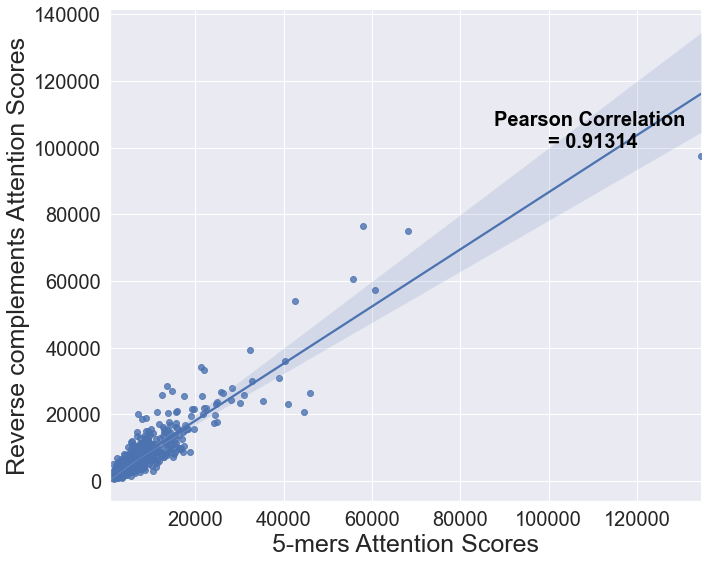

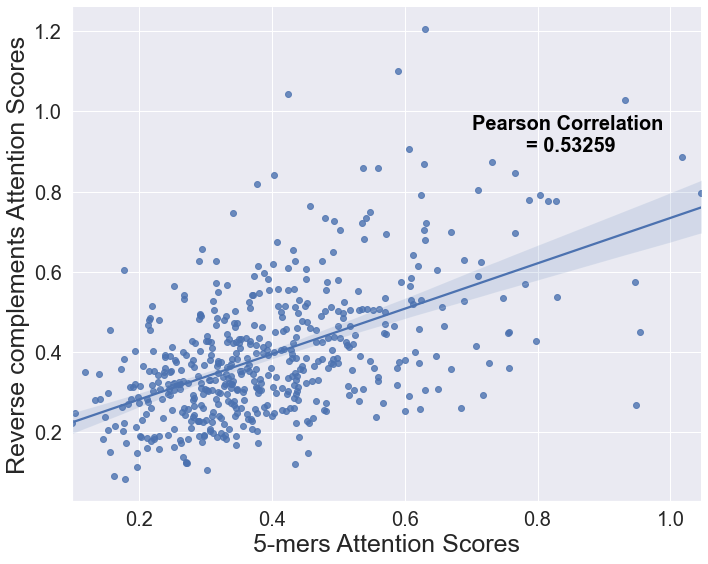

In [120]:
fig_path='/home/yibei/Projects/nucleosome_occupancy/figs/'
fig_path='/Users/yibeijia/Downloads/nucleosome_occupancy/figs/'

reverseCompPlot(ordered_map, fig_path + 'ordered_map_all.png', 110000, 100000)
reverseCompPlot(ordered_map_norm, fig_path + 'ordered_map_all_norm.png', .85, .90)


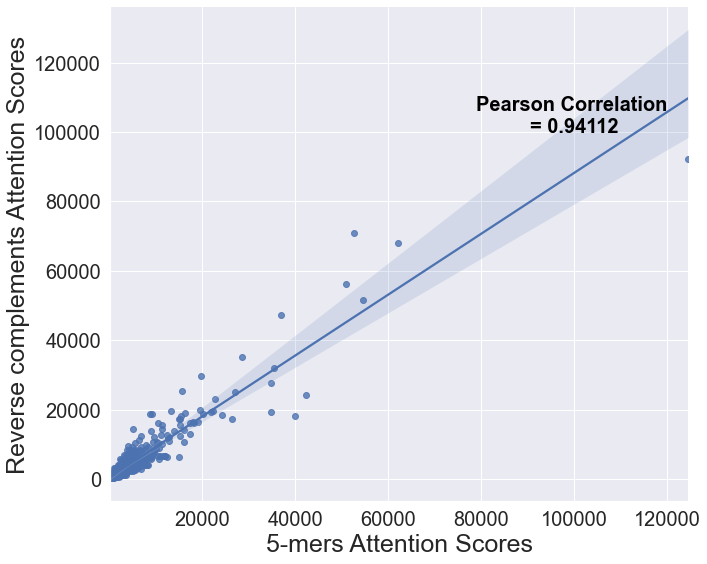

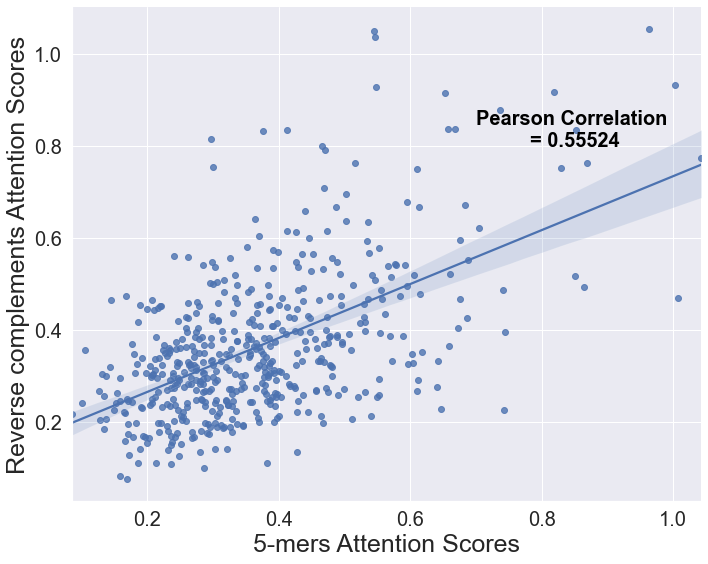

In [122]:
reverseCompPlot(ordered_map0, fig_path + 'ordered_map_0.png', 100000, 100000)
reverseCompPlot(ordered_map_norm0, fig_path + 'ordered_map_0_norm.png', 0.85, 0.8)

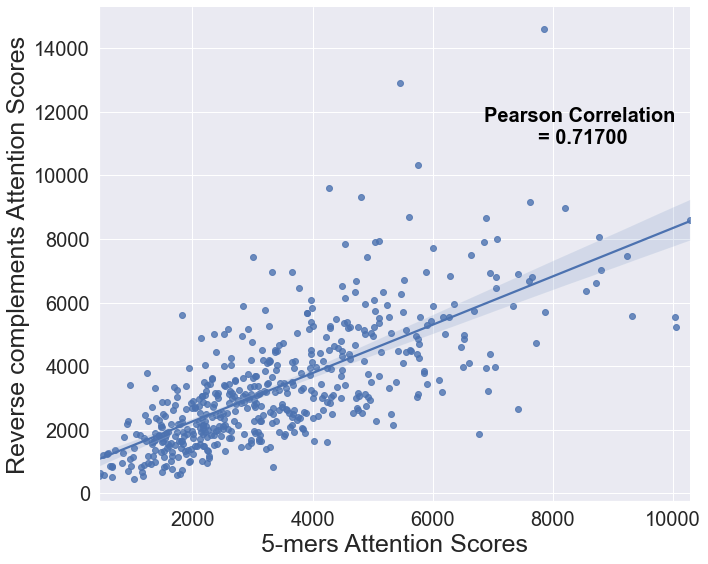

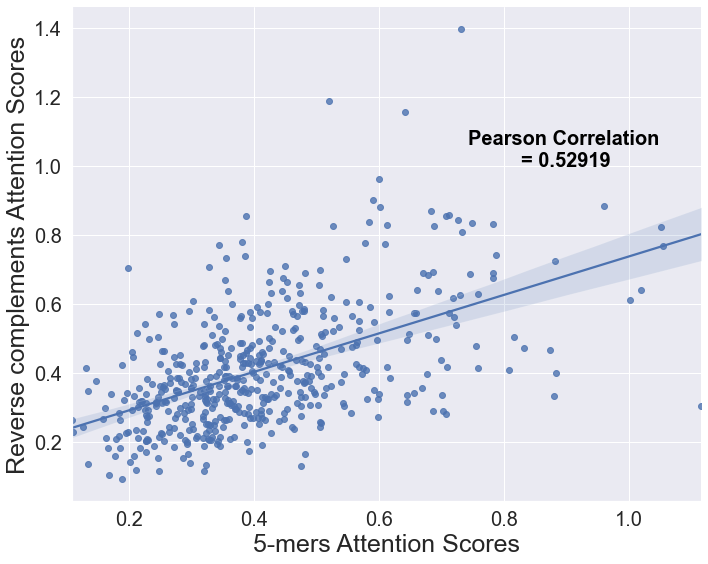

In [125]:
reverseCompPlot(ordered_map1, fig_path + 'ordered_map_1.png', 8500, 11000)
reverseCompPlot(ordered_map_norm1, fig_path + 'ordered_map_1_norm.png',.9, 1)

## 1.2 Add reverse complement scores to 5mer scores

In [49]:
def addReversCompScores(attention_outputs, d):
    # if you are using batches the outputs will be in batches
    # get exact attentions of chars
    from IPython.display import display
    mapped_add = {}
#     testmat = scipy.io.loadmat(data_folder+'Test_data.mat')
#     d = testmat['Test_data']
    for seq in range(len(attention_outputs)):
    # for seq in range(1,5):

        # tokens are the 5mers in the current sequence
        tokens = tokenize(ReverseOneHotEncode(d[seq]))

        # for 147bp each sequence, there are 320 feature scores for each bp
        for i in range(len(tokens)):
            token = tokens[i]
            five_mer_attention_output = sum(attention_outputs[seq][i])
            if token in mapped_add.keys():  # if a 5mer is found
                mapped_add[token] = mapped_add[token] + five_mer_attention_output #increase value
                mapped_add[reverse_complement(token)] = mapped_add[token] #set the reverse compliement value to the same

            # if a 5mer's reverse complement is found
            elif reverse_complement(token) in mapped_add.keys():
                mapped_add[reverse_complement(token)] = mapped_add[reverse_complement(token)] + five_mer_attention_output
                mapped_add[token] = mapped_add[reverse_complement(token)] #set the original 5mer value to the same

            #if 5mer not seen yet
            else: 
                mapped_add[token] = five_mer_attention_output
                mapped_add[reverse_complement(token)] = mapped_add[token]
    #     char_df = plot_attention_from_seq(tokens, mapped[token])
    #     display(char_df)

    # Plot the mapped dictionary for each 5 mer; Darker means higher attention score
    import collections
    ordered_map_add = collections.OrderedDict(sorted(mapped_add.items()))
    # char_df = plot_attention_from_map(mapped_add)
    # display(char_df)
    # char_df = plot_attention_from_map(ordered_map_add)
    # display(char_df)
    return ordered_map_add

In [50]:
data_folder = "/Users/yibeijia/Downloads/nucleosome_occupancy/data/train_test_data/"

# load testmat from file
testmat = scipy.io.loadmat(data_folder+'Test_data.mat')
    
d=testmat['Test_data'] # need to redefine d
labels = testmat['Test_labels']
new_labels = labels[0]

# get the index of data that is 0 or 1 
ones = np.flatnonzero(new_labels == np.max(new_labels))
zeros = np.flatnonzero(new_labels == np.min(new_labels))
d0 = [d[i] for i in zeros]
d1 = [d[i] for i in ones]

ordered_map_add0 = addReversCompScores(attention_outputs0, d0)
print("done1")
ordered_map_add1 = addReversCompScores(attention_outputs1, d1)
print("done2")
ordered_map_add = addReversCompScores(attention_outputs, d)
print("done")

done1
done2
done


In [51]:
# print(ordered_kmerCounts.keys())
def normKmerCount_addReverse(ordered_map, kmerCounts):
    ordered_map_add_norm = {}
    for k, _ in ordered_map.items():
        r = reverse_complement(k)
        v = ordered_map[k] / (kmerCounts[k] + kmerCounts[r])
        ordered_map_add_norm[k] = v
    return ordered_map_add_norm

In [52]:
ordered_map_add_norm = normKmerCount_addReverse(ordered_map_add, kmerCounts)
print(len(ordered_map_add_norm))
print(len(ordered_map_add))
ordered_map_add_norm0 = normKmerCount_addReverse(ordered_map_add0, kmerCounts0)
ordered_map_add_norm1 = normKmerCount_addReverse(ordered_map_add1, kmerCounts1)

1024
1024


In [88]:
ordered_map_add1['ATATA']

12851.641639819081

In [59]:
kmerCounts0['ATATA'] + kmerCounts0[reverse_complement('ATATA')]

129099

In [60]:
ordered_map_add_norm0['ATATA']

1.008918739409122

In [435]:
ordered_map['CGCGC']

1102.0354292728

In [436]:
ordered_map['ATATA']

67960.42427976173

In [437]:
ordered_map['AAAAA']

120505.95015182017

## 3. Plot correlation for attention scores and DNA shape

In [137]:
# #################### Add person correlation annotation All Normalized ###################
# def pearsonBarPlot(shape_df, whichattention, fname):
#     from scipy import stats
#     AllDNAshape = ['Shear', 'Stretch', 'Stagger', 'Buckle', 'Propel', 'Opening', 
#     'Shift_-1', 'Shift_1', 'Slide_-1', 'Slide_1', 'Rise_-1', 'Rise_1',
#                 'Tilt_-1', 'Tilt_1', 
#     'Roll_-1', 'Roll_1', 'Twist_-1', 'Twist_1', 'mingw', 'mingd', 'majgw', 'majgd', 
#     'Shear-SD', 'Stretch-SD', 'Stagger-SD', 'Buckle-SD', 'Propel-SD', 'Opening-SD', 
#     'Shift-SD', 'Slide-SD', 'Rise-SD', 'Tilt-SD', 'Roll-SD', 'Twist-SD', 'mingw-SD', 
#     'mingd-SD', 'majgw-SD', 'majgd-SD']
#     pearson=[]
#     p_val=[]
#     all_shape_df = {}
#     for shape in AllDNAshape:
#         cor = stats.pearsonr(shape_df[shape], shape_df[whichattention])[0]
#         pval = stats.pearsonr(shape_df[shape], shape_df[whichattention])[0]
#         r2 = stats.pearsonr(shape_df[shape], shape_df[whichattention])[0]**2
#         all_shape_df[shape] = [cor]
#     #     pearson.append(cor)
#     #     p_val.append(pval)
#     #     print(f"{shape} vs. attention_score | Pearson: {cor:.5f}, P-value {pval:.5f} | R^2: {r2:.5f}")

#     df = pd.DataFrame.from_dict(all_shape_df, orient='index', columns=['Pearson'])
#     df["Shapes"] =all_shape_df.keys()

#     df = df.sort_values(by=['Pearson'])
#     # df = df.T
#     df_sorted = df
#     # print(df_sorted)
#     shape_ordered = df_sorted.keys()
#     # f, ax = plt.subplots(figsize=(7, 3))

#     ax = sns.catplot(y="Shapes",x="Pearson",data=df_sorted, kind="bar", edgecolor=".6", height=10, aspect=.8)
#     ax.set_axis_labels("Pearson Correlation", "Shapes", fontsize=18)
#     ax.set_yticklabels(fontsize=12)
#     ax.set_xticklabels(fontsize=12)

#     # plt.gcf().set_size_inches(35, 8)

#     # ax.set_xticklabels(ax.get_xticklabels(),rotation = 30, fontsize=20)
#     # ax.set_ylim(-0.6, 0.6)
#     # ax.set_xlabel('Shape', fontsize=33)
#     # ax.set_ylabel('Attention Score', fontsize=35)
#     # ax.set_title("Average Shape Attention Score Correlations", fontsize=50)
#     plt.tight_layout()
#     plt.savefig( fig_path + fname, dpi=200)

In [136]:
# ################################### Correlation plots for DNA shape ###################################
# import seaborn as sns
# import matplotlib.pyplot

# # use added reverse complement score way
# attention_score = []

# for k in tb.items(): # set values to the 5mer order as seen in tb
#     attention_score.append(ordered_map_add[k[0]]) 
# #     attention_score_norm.append(ordered_map_add_norm[k[0]]) 
    
# shape_df =  pd.DataFrame.from_dict(tb,orient='index', columns=['Shear', 'Stretch', 'Stagger', 'Buckle', 'Propel', 'Opening', 
# 'Shift_-1', 'Shift_1', 'Slide_-1', 'Slide_1', 'Rise_-1', 'Rise_1','Tilt_-1', 'Tilt_1', 
# 'Roll_-1', 'Roll_1', 'Twist_-1', 'Twist_1', 'mingw', 'mingd', 'majgw', 'majgd', 
# 'Shear-SD', 'Stretch-SD', 'Stagger-SD', 'Buckle-SD', 'Propel-SD', 'Opening-SD', 
# 'Shift-SD', 'Slide-SD', 'Rise-SD', 'Tilt-SD', 'Roll-SD', 'Twist-SD', 'mingw-SD', 
# 'mingd-SD', 'majgw-SD', 'majgd-SD'])
# # print(shape_df)
# shape_df['attention_score'] = attention_score
# # shape_df['attention_score_norm'] = attention_score_norm
# # shape_df['attention_score_norm0'] = attention_score_norm0
# # shape_df['attention_score_norm1'] = attention_score_norm1
# # print(shape_df)
# sns.set_theme(style="darkgrid")

# # sns.pairplot(shape_df);

# pearsonBarPlot(shape_df, 'attention_score', 'shape_attention_corr_bar.png')


In [133]:
# #################### Add person correlation annotation ABS SORTED ###################
# from scipy import stats
# AllDNAshape = ['Shear', 'Stretch', 'Stagger', 'Buckle', 'Propel', 'Opening', 
# 'Shift_-1', 'Shift_1', 'Slide_-1', 'Slide_1', 'Rise_-1', 'Rise_1',
#             'Tilt_-1', 'Tilt_1', 
# 'Roll_-1', 'Roll_1', 'Twist_-1', 'Twist_1', 'mingw', 'mingd', 'majgw', 'majgd', 
# 'Shear-SD', 'Stretch-SD', 'Stagger-SD', 'Buckle-SD', 'Propel-SD', 'Opening-SD', 
# 'Shift-SD', 'Slide-SD', 'Rise-SD', 'Tilt-SD', 'Roll-SD', 'Twist-SD', 'mingw-SD', 
# 'mingd-SD', 'majgw-SD', 'majgd-SD']
# pearson=[]
# p_val=[]
# all_shape_df = {}
# for shape in AllDNAshape:
#     cor = stats.pearsonr(shape_df[shape], shape_df['attention_score_norm'])[0]
#     pval = stats.pearsonr(shape_df[shape], shape_df['attention_score_norm'])[0]
#     r2 = stats.pearsonr(shape_df[shape], shape_df['attention_score_norm'])[0]**2
#     all_shape_df[shape] = [abs(cor)]
# #     pearson.append(cor)
# #     p_val.append(pval)
# #     print(f"{shape} vs. attention_score | Pearson: {cor:.5f}, P-value {pval:.5f} | R^2: {r2:.5f}")
# df = pd.DataFrame.from_dict(all_shape_df, orient='index', columns=['Pearson']).sort_values(by=['Pearson'])
# df = df.T
# df_sorted = df
# shape_ordered = df_sorted.keys()
# ax = sns.barplot(data=df_sorted)
# plt.gcf().set_size_inches(35, 8)

# ax.set_xticklabels(ax.get_xticklabels(),rotation = 30, fontsize=20)
# ax.set_ylim(-0.6, 0.6)
# ax.set_xlabel('Shape', fontsize=33)
# ax.set_ylabel('Attention Score', fontsize=35)
# ax.set_title("Average Shape Attention Score Correlations", fontsize=50)
# plt.tight_layout()
# plt.savefig( fig_path + 'shape_attention_corr_bar.png', dpi=200)

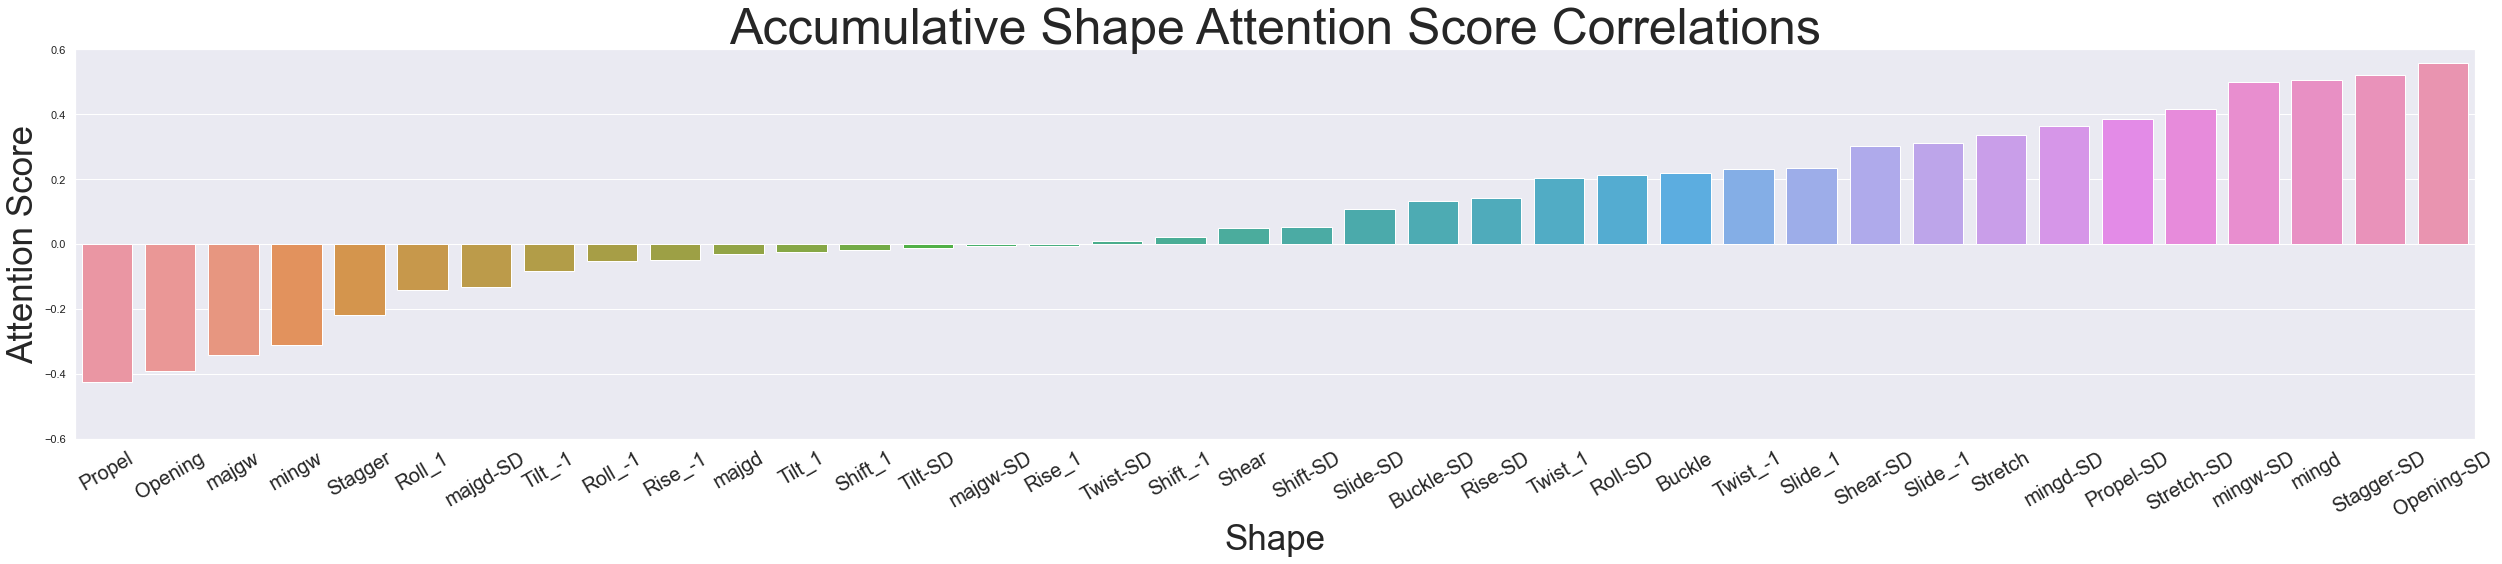

In [89]:
# #################### Add person correlation annotation - UNNORMALIZED ###################
# from scipy import stats
# AllDNAshape = ['Shear', 'Stretch', 'Stagger', 'Buckle', 'Propel', 'Opening', 
# 'Shift_-1', 'Shift_1', 'Slide_-1', 'Slide_1', 'Rise_-1', 'Rise_1',
#             'Tilt_-1', 'Tilt_1', 
# 'Roll_-1', 'Roll_1', 'Twist_-1', 'Twist_1', 'mingw', 'mingd', 'majgw', 'majgd', 
# 'Shear-SD', 'Stretch-SD', 'Stagger-SD', 'Buckle-SD', 'Propel-SD', 'Opening-SD', 
# 'Shift-SD', 'Slide-SD', 'Rise-SD', 'Tilt-SD', 'Roll-SD', 'Twist-SD', 'mingw-SD', 
# 'mingd-SD', 'majgw-SD', 'majgd-SD']
# pearson=[]
# p_val=[]
# all_shape_df = {}
# for shape in AllDNAshape:
#     cor = stats.pearsonr(shape_df[shape], shape_df['attention_score'])[0]
#     pval = stats.pearsonr(shape_df[shape], shape_df['attention_score'])[0]
#     r2 = stats.pearsonr(shape_df[shape], shape_df['attention_score'])[0]**2
#     all_shape_df[shape] = [cor]
# #     pearson.append(cor)
# #     p_val.append(pval)
# #     print(f"{shape} vs. attention_score | Pearson: {cor:.5f}, P-value {pval:.5f} | R^2: {r2:.5f}")
# df = pd.DataFrame.from_dict(all_shape_df, orient='index', columns=['Pearson']).sort_values(by=['Pearson'])
# df = df.T
# df_sorted = df
# shape_ordered = df_sorted.keys()
# ax = sns.barplot(data=df_sorted)
# plt.gcf().set_size_inches(35, 8)

# ax.set_xticklabels(ax.get_xticklabels(),rotation = 30, fontsize=20)
# ax.set_ylim(-0.6, 0.6)
# ax.set_xlabel('Shape', fontsize=35)
# ax.set_ylabel('Attention Score', fontsize=35)
# ax.set_title("Accumulative Shape Attention Score Correlations", fontsize=50)
# plt.tight_layout()
# plt.savefig( fig_path + 'accum_shape_attention_corr_bar.png', dpi=200)

In [ ]:
shape_ordered

In [ ]:
idx = pearson.index(max(pearson))
s = AllDNAshape[idx]
m = max(pearson)
print(idx)
p = p_val[idx]
print(f"Most correlated shape is {s} with Pearson: {m:.5f}, P-value {p:.5f}") 

# 3. Shape vs Attention Score Corr Bar plots

In [185]:
#################### Add person correlation annotation All Normalized ###################
def plotAttention(whichAttention, shape_order, title):
    from scipy import stats
    AllDNAshape = ['Shear', 'Stretch', 'Stagger', 'Buckle', 'Propel', 'Opening', 
    'Shift_-1', 'Shift_1', 'Slide_-1', 'Slide_1', 'Rise_-1', 'Rise_1',
                'Tilt_-1', 'Tilt_1', 
    'Roll_-1', 'Roll_1', 'Twist_-1', 'Twist_1', 'mingw', 'mingd', 'majgw', 'majgd', 
    'Shear-SD', 'Stretch-SD', 'Stagger-SD', 'Buckle-SD', 'Propel-SD', 'Opening-SD', 
    'Shift-SD', 'Slide-SD', 'Rise-SD', 'Tilt-SD', 'Roll-SD', 'Twist-SD', 'mingw-SD', 
    'mingd-SD', 'majgw-SD', 'majgd-SD']
    
    all_shape_df = {}
    for shape in AllDNAshape:
        cor = stats.pearsonr(shape_df[shape], shape_df[whichAttention])[0]
        pval = stats.pearsonr(shape_df[shape], shape_df[whichAttention])[0]
        r2 = stats.pearsonr(shape_df[shape], shape_df[whichAttention])[0]**2
        all_shape_df[shape] = [cor]

    #     print(f"{shape} vs. attention_score | Pearson: {cor:.5f}, P-value {pval:.5f} | R^2: {r2:.5f}")

    df = pd.DataFrame.from_dict(all_shape_df, orient='index', columns=['Pearson'])
    df["Shapes"] =all_shape_df.keys()
    
#     if (whichAttention == 'attention_score' or whichAttention == 'attention_score_norm'):
    if (whichAttention == 'attention_score'):
        df_sorted = df.sort_values(by=['Pearson'])
        shape_order = df_sorted['Shapes']
    else:
        for s in range(len(shape_order)):
            df.loc[shape_order[s], 'order'] = s
        df_sorted = df.sort_values(by=['order'])
#     p= sns.color_palette("Greens_d", len(df_sorted))
    p= sns.color_palette("mako", len(df_sorted))
    rank = df_sorted["Pearson"].argsort().argsort()
    
    #rocket
    ax = sns.catplot(y="Shapes",x="Pearson",data=df_sorted, kind="bar", edgecolor=".6", height=10,palette=np.array(p[::-1])[rank])

    ax.set_axis_labels("Pearson Correlation", "Shapes", fontsize=18)
    ax.set_yticklabels(fontsize=12)
    ax.set_xticklabels(fontsize=12)
    ax.set_titles(title,fontsize=12)

    plt.tight_layout()
    plt.title(whichAttention)
    if whichAttention == 'attention_score': whichAttention=whichAttention+"_all"
    if whichAttention == 'attention_score_norm': whichAttention=whichAttention+"norm_all"
    plt.savefig( fig_path + whichAttention + '.png', dpi=200, bbox_inches='tight')
    return shape_order


Propel            Propel
Opening          Opening
majgw              majgw
mingw              mingw
Stagger          Stagger
Roll_1            Roll_1
majgd-SD        majgd-SD
Tilt_-1          Tilt_-1
Roll_-1          Roll_-1
Rise_-1          Rise_-1
majgd              majgd
Tilt_1            Tilt_1
Shift_1          Shift_1
Tilt-SD          Tilt-SD
majgw-SD        majgw-SD
Rise_1            Rise_1
Twist-SD        Twist-SD
Shift_-1        Shift_-1
Shear              Shear
Shift-SD        Shift-SD
Slide-SD        Slide-SD
Buckle-SD      Buckle-SD
Rise-SD          Rise-SD
Twist_1          Twist_1
Roll-SD          Roll-SD
Buckle            Buckle
Twist_-1        Twist_-1
Slide_1          Slide_1
Shear-SD        Shear-SD
Slide_-1        Slide_-1
Stretch          Stretch
mingd-SD        mingd-SD
Propel-SD      Propel-SD
Stretch-SD    Stretch-SD
mingw-SD        mingw-SD
mingd              mingd
Stagger-SD    Stagger-SD
Opening-SD    Opening-SD
Name: Shapes, dtype: object

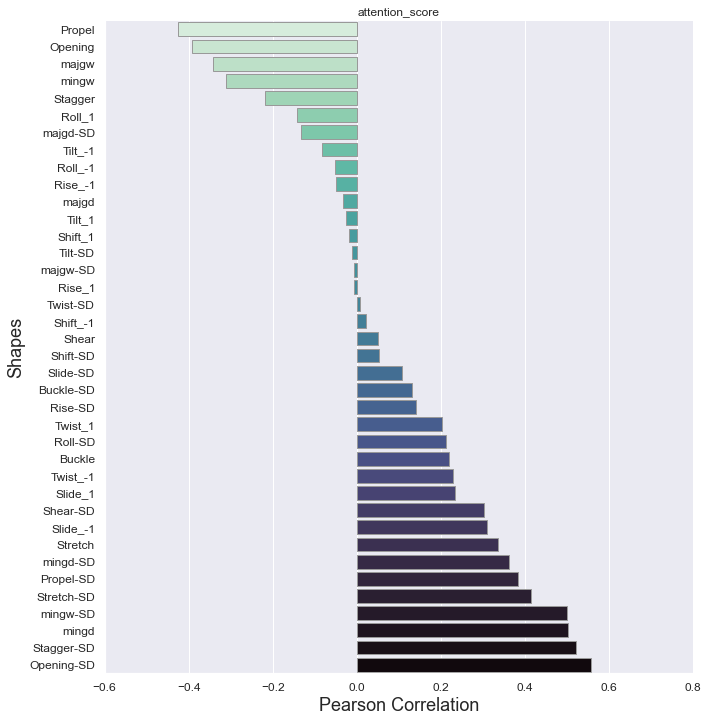

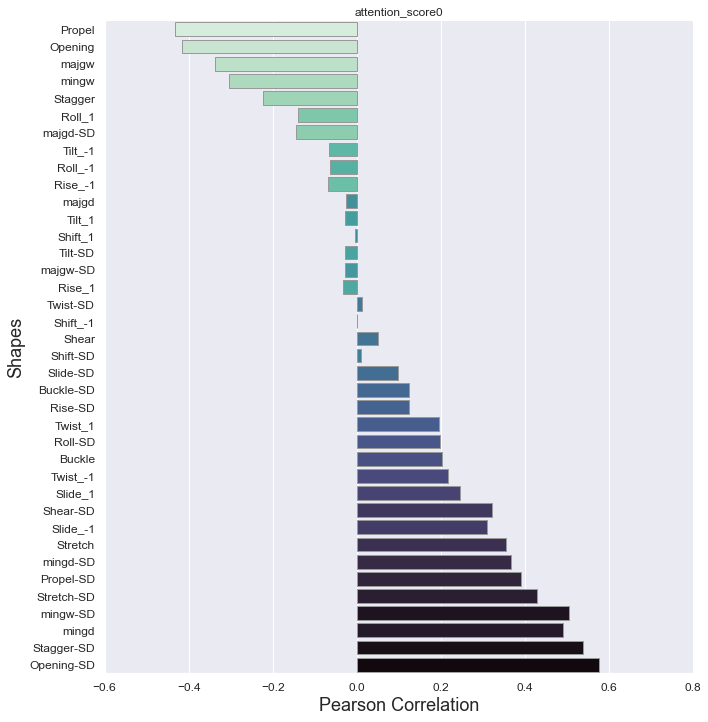

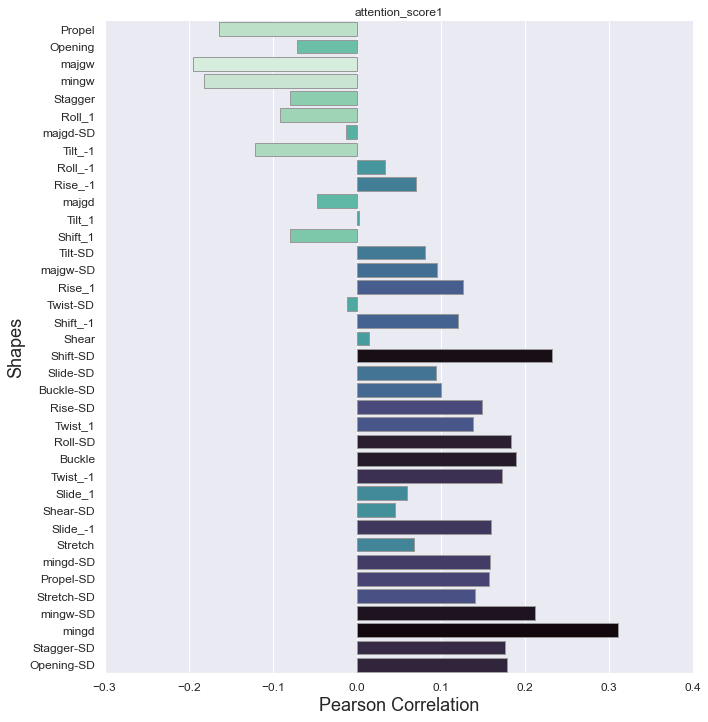

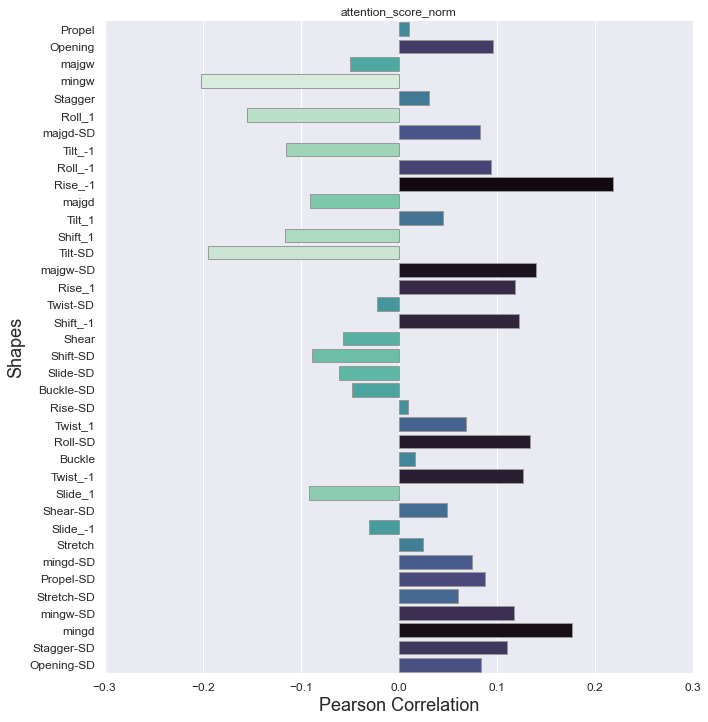

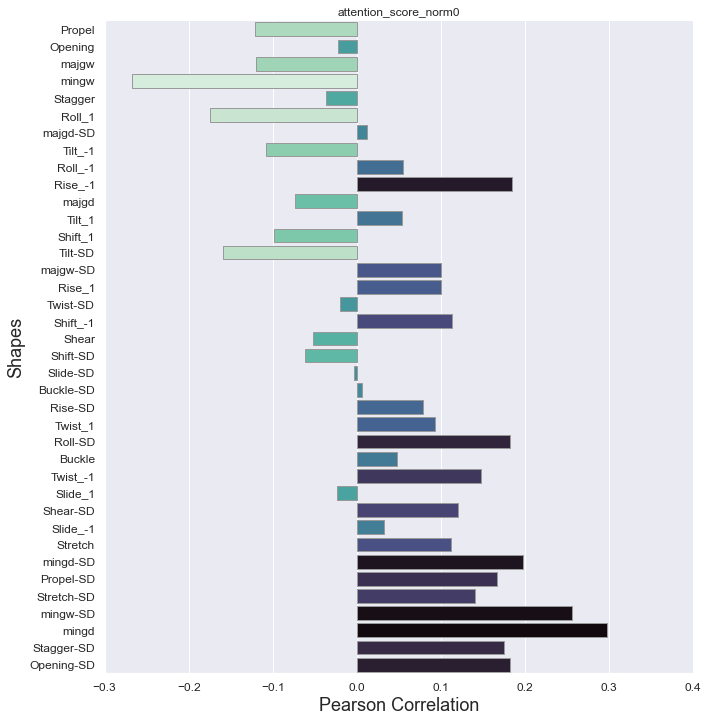

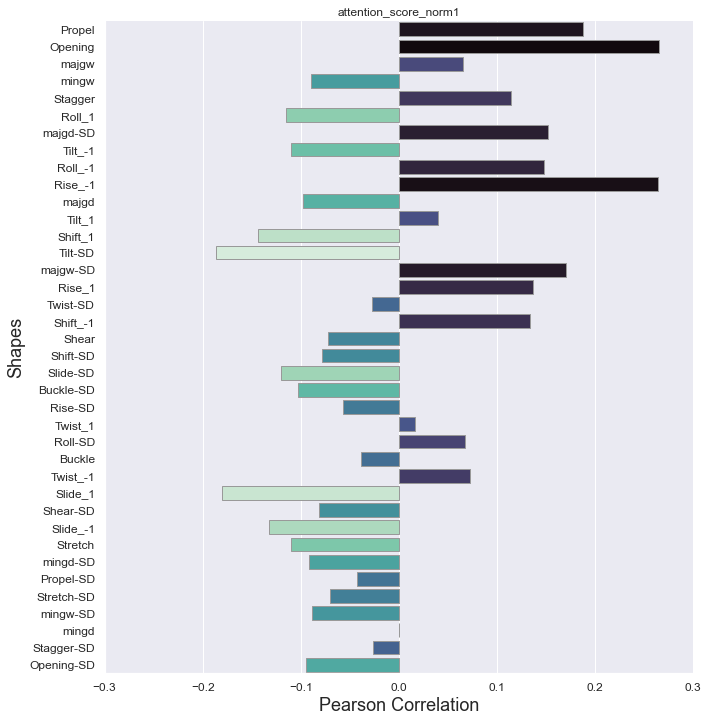

In [186]:
################################### Correlation plots for DNA shape ###################################
import seaborn as sns
import matplotlib.pyplot

# use added reverse complement score way
attention_score0 = []
attention_score1 = []
attention_score = []
attention_score_norm0 = []
attention_score_norm1 = []
attention_score_norm = []

for k in tb.items(): # set values to the 5mer order as seen in tb
    attention_score.append(ordered_map_add[k[0]]) 
    attention_score0.append(ordered_map_add0[k[0]])
    attention_score1.append(ordered_map_add1[k[0]])
    
    attention_score_norm.append(ordered_map_add_norm[k[0]]) 
    attention_score_norm0.append(ordered_map_add_norm0[k[0]])
    attention_score_norm1.append(ordered_map_add_norm1[k[0]])

shape_df =  pd.DataFrame.from_dict(tb,orient='index', columns=['Shear', 'Stretch', 'Stagger', 'Buckle', 'Propel', 'Opening', 
'Shift_-1', 'Shift_1', 'Slide_-1', 'Slide_1', 'Rise_-1', 'Rise_1','Tilt_-1', 'Tilt_1', 
'Roll_-1', 'Roll_1', 'Twist_-1', 'Twist_1', 'mingw', 'mingd', 'majgw', 'majgd', 
'Shear-SD', 'Stretch-SD', 'Stagger-SD', 'Buckle-SD', 'Propel-SD', 'Opening-SD', 
'Shift-SD', 'Slide-SD', 'Rise-SD', 'Tilt-SD', 'Roll-SD', 'Twist-SD', 'mingw-SD', 
'mingd-SD', 'majgw-SD', 'majgd-SD'])
# print(shape_df)
shape_df['attention_score'] = attention_score
shape_df['attention_score0'] = attention_score0
shape_df['attention_score1'] = attention_score1

shape_df['attention_score_norm'] = attention_score_norm
shape_df['attention_score_norm0'] = attention_score_norm0
shape_df['attention_score_norm1'] = attention_score_norm1

shape_ordered = plotAttention('attention_score', [],'Attention Score' )
plotAttention('attention_score0', shape_ordered, 'Attention Score for Nucleosome Depleted Sequences')
plotAttention('attention_score1', shape_ordered, 'Attention Score for Nucleosome Enriched Sequences' )

# shape_ordered = plotAttention('attention_score_norm', [],'Attention Score Normalized' )
plotAttention('attention_score_norm', shape_ordered,'Attention Score Normalized' )
plotAttention('attention_score_norm0', shape_ordered, 'Attention Score for Nucleosome Depleted Sequences Normalized')
plotAttention('attention_score_norm1', shape_ordered, 'Attention Score for Nucleosome Enriched Sequences Normalized' )



In [143]:
shape_df

,Shear,Stretch,Stagger,Buckle,Propel,Opening,Shift_-1,Shift_1,Slide_-1,Slide_1,...,Tilt-SD,Roll-SD,Twist-SD,mingw-SD,mingd-SD,majgw-SD,majgd-SD,attention_score,attention_score0,attention_score1
AAAAA,0.18,0.03,-0.22,7.80,-16.51,-3.71,-0.20,-0.08,-0.97,-0.99,...,0.68,2.77,0.99,0.96,0.18,0.48,0.69,232068.787709,216806.230529,15262.557179
AAAAC,0.15,-0.01,-0.06,9.07,-14.47,-1.90,-0.11,0.13,-1.01,-1.11,...,0.41,2.31,0.69,0.71,0.16,0.36,0.92,44390.575104,35488.599958,8901.975145
AAAAG,0.17,0.01,-0.13,7.39,-14.68,-2.30,-0.11,0.20,-1.05,-1.23,...,0.51,2.25,0.75,0.61,0.11,0.37,0.83,62837.906330,52229.510700,10608.395630
AAAAT,0.17,-0.01,-0.10,7.97,-14.89,-2.05,-0.05,0.11,-1.08,-1.22,...,0.42,2.20,0.67,0.58,0.11,0.37,0.60,134422.601581,123812.499909,10610.101673
AAACA,0.15,-0.01,0.13,11.53,-13.05,-1.30,0.00,0.50,-1.06,-1.54,...,0.99,1.99,0.93,0.69,0.19,0.33,0.56,36512.210026,26956.364173,9555.845853
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGCCA,0.27,-0.03,0.11,-1.54,-2.98,0.21,-0.03,-0.10,-1.58,-1.71,...,0.50,0.59,1.64,0.24,0.09,0.45,1.54,15978.520187,5990.578938,9987.941249
TGGAA,-0.29,-0.04,-0.01,0.12,-5.20,0.25,0.06,-0.27,-1.77,-1.48,...,0.66,0.71,1.20,0.17,0.08,0.49,1.87,24333.503394,14306.371384,10027.132010
TGTAA,-0.11,-0.03,0.12,-0.58,-7.55,-1.07,-0.23,-0.08,-1.50,-1.29,...,0.68,4.29,0.71,0.28,0.14,0.61,1.23,18507.876702,13455.775695,5052.101006
TTAAA,0.12,-0.00,-0.16,0.32,-10.70,-1.68,-0.04,-0.23,-1.09,-1.05,...,0.51,4.52,0.73,0.50,0.09,0.20,0.33,27605.210869,24834.756368,2770.454500


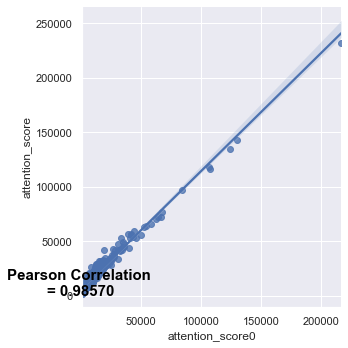

In [154]:
sns.set_theme(style="darkgrid")

sns.lmplot(x="attention_score0", y="attention_score",data=shape_df);
from scipy import stats
num = stats.pearsonr(shape_df['attention_score0'], shape_df['attention_score'])[0]
text = "Pearson Correlation \n= " + f'{num:.5f}'

plt.text(0, 0, text, horizontalalignment='center', fontsize=15, color='black', weight='semibold')
plt.tight_layout()



In [156]:
print(stats.pearsonr(shape_df['attention_score0'], shape_df['attention_score'])[0])
print(stats.pearsonr(shape_df['attention_score1'], shape_df['attention_score'])[0])
print(stats.pearsonr(shape_df['attention_score0'], shape_df['attention_score1'])[0])

0.9856998534974288
0.5590410524450529
0.4113278662712485
